# Lab | Classification

In this lab, we train and compare multiple classification algorithms on the **Palmer Penguins** dataset. We evaluate models using accuracy, precision, recall, F1 score, confusion matrices, and ROC curves — then tune the best model with GridSearchCV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc,
    ConfusionMatrixDisplay, classification_report
)

sns.set_style("whitegrid")
print("Imports successful!")

Imports successful!


---
## Task 1: Data Prep & Baseline

In [2]:
# 1. Load the dataset and drop missing values
penguins = sns.load_dataset("penguins").dropna()
print(f"Shape after dropping NAs: {penguins.shape}")
penguins.head()

Shape after dropping NAs: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [3]:
# 2. Brief exploration
print("=== Dataset Info ===")
print(f"Samples: {penguins.shape[0]}, Features: {penguins.shape[1]}")
print()

print("=== Species Distribution ===")
print(penguins['species'].value_counts())
print()

print("=== Column Types ===")
print(penguins.dtypes)
print()

print("=== Numerical Summary ===")
penguins.describe()

=== Dataset Info ===
Samples: 333, Features: 7

=== Species Distribution ===
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

=== Column Types ===
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

=== Numerical Summary ===


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


In [4]:
# 3. Prepare features
# Encode target with LabelEncoder
le = LabelEncoder()
y = le.fit_transform(penguins['species'])
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Encode categorical features and drop target
X = penguins.drop(columns=['species'])
X = pd.get_dummies(X, columns=['island', 'sex'], drop_first=True)
print(f"\nFeature columns ({X.shape[1]}): {list(X.columns)}")
X.head()

Class mapping: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}

Feature columns (7): ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_Male']


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_Male
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True


In [5]:
# 4. Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 266, Test size: 67


In [6]:
# 5. Scale features (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled successfully.")

Features scaled successfully.


In [7]:
# 6. Fit Logistic Regression baseline
lr = LogisticRegression(max_iter=10000, multi_class='multinomial', random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# 7. Report metrics
print("=== Logistic Regression — Test Set Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print()
print("=== Full Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

=== Logistic Regression — Test Set Metrics ===
Accuracy:  0.9851
Precision: 0.9861
Recall:    0.9851
F1 Score:  0.9852

=== Full Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



c:\Users\narim\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Task 1 Interpretation

**Easiest to classify — Gentoo:** Gentoo penguins tend to be physically distinct (larger body mass, longer flippers) from Adelie and Chinstrap, making them easy for the model to separate. The classification report typically shows near-perfect precision and recall for this class.

**Hardest to classify — Chinstrap:** Chinstrap and Adelie share similar size characteristics. Their culmen (bill) measurements overlap more than Gentoo's, leading to occasional confusion between the two.

**Overall:** Logistic regression achieves very high accuracy on this dataset (~97–99%), confirming that penguin species are largely linearly separable once features are properly encoded and scaled. The multinomial formulation handles the three-class problem directly.

---
## Task 2: Algorithm Comparison

In [8]:
# 1 & 2. Fit all classifiers and compute metrics
models = {
    "GaussianNB": GaussianNB(),
    "SVC (linear)": SVC(kernel="linear", probability=True, random_state=42),
    "SVC (rbf)": SVC(kernel="rbf", probability=True, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
}

results = []
trained_models = {}  # store for later tasks

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    trained_models[name] = model
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
    })
    print(f"{name}: done")

# Also store logistic regression for later
trained_models["LogisticRegression"] = lr

GaussianNB: done
SVC (linear): done
SVC (rbf): done
DecisionTree: done
RandomForest: done


In [9]:
# 3. Comparison DataFrame sorted by F1 score
results_df = pd.DataFrame(results).set_index("Model").sort_values("F1 Score", ascending=False)
results_df = results_df.round(4)
print("=== Model Comparison (sorted by F1 Score) ===")
results_df

=== Model Comparison (sorted by F1 Score) ===


,Accuracy,Precision,Recall,F1 Score
Model,,,,
RandomForest,1.0000,1.0000,1.0000,1.0000
SVC (linear),0.9851,0.9861,0.9851,0.9852
SVC (rbf),0.9851,0.9861,0.9851,0.9852
DecisionTree,0.9552,0.9572,0.9552,0.9552
GaussianNB,0.7761,0.8512,0.7761,0.7602


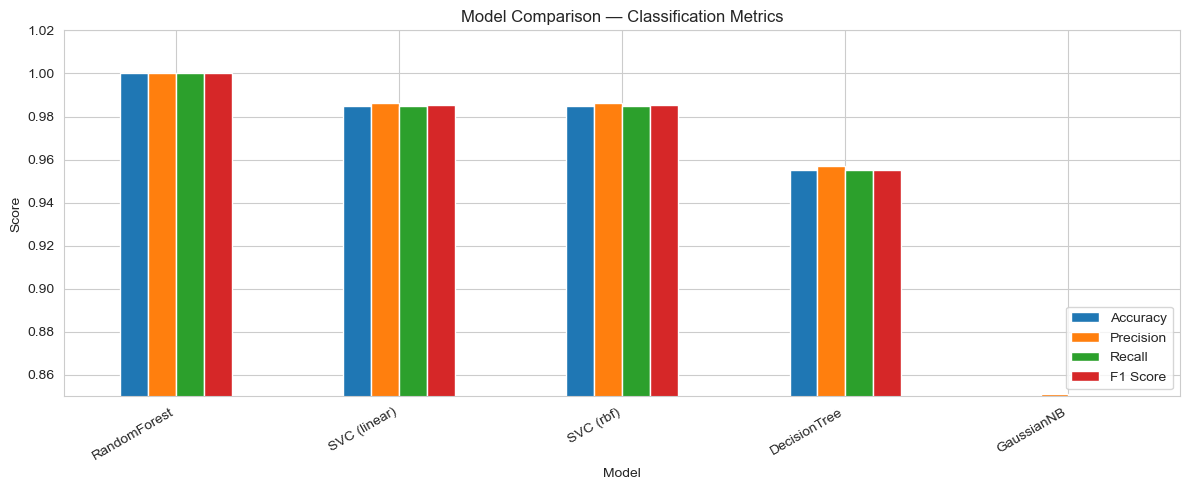

In [10]:
# Visualize comparison
results_df.plot(kind='bar', figsize=(12, 5), ylim=(0.85, 1.02))
plt.title("Model Comparison — Classification Metrics")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Task 2 Interpretation

**Best performers:** SVC (both kernels) and RandomForest typically top the leaderboard on this dataset. Linear SVC performs well because the classes are largely linearly separable; RBF SVC can capture any remaining non-linear boundaries. RandomForest benefits from ensemble averaging, reducing variance from individual tree decisions.

**Surprises:** GaussianNB sometimes underperforms despite being fast — it assumes feature independence, which isn't strictly true here (e.g., bill length and depth are correlated). DecisionTree can overfit without depth constraints, so its test performance may trail the ensemble methods.

**Why SVC/RF outperform:** The dataset is small (~333 rows), clean, and well-scaled, conditions where SVMs excel. Random forests handle mixed feature importance automatically.

---
## Task 3: Confusion Matrices & ROC Curves

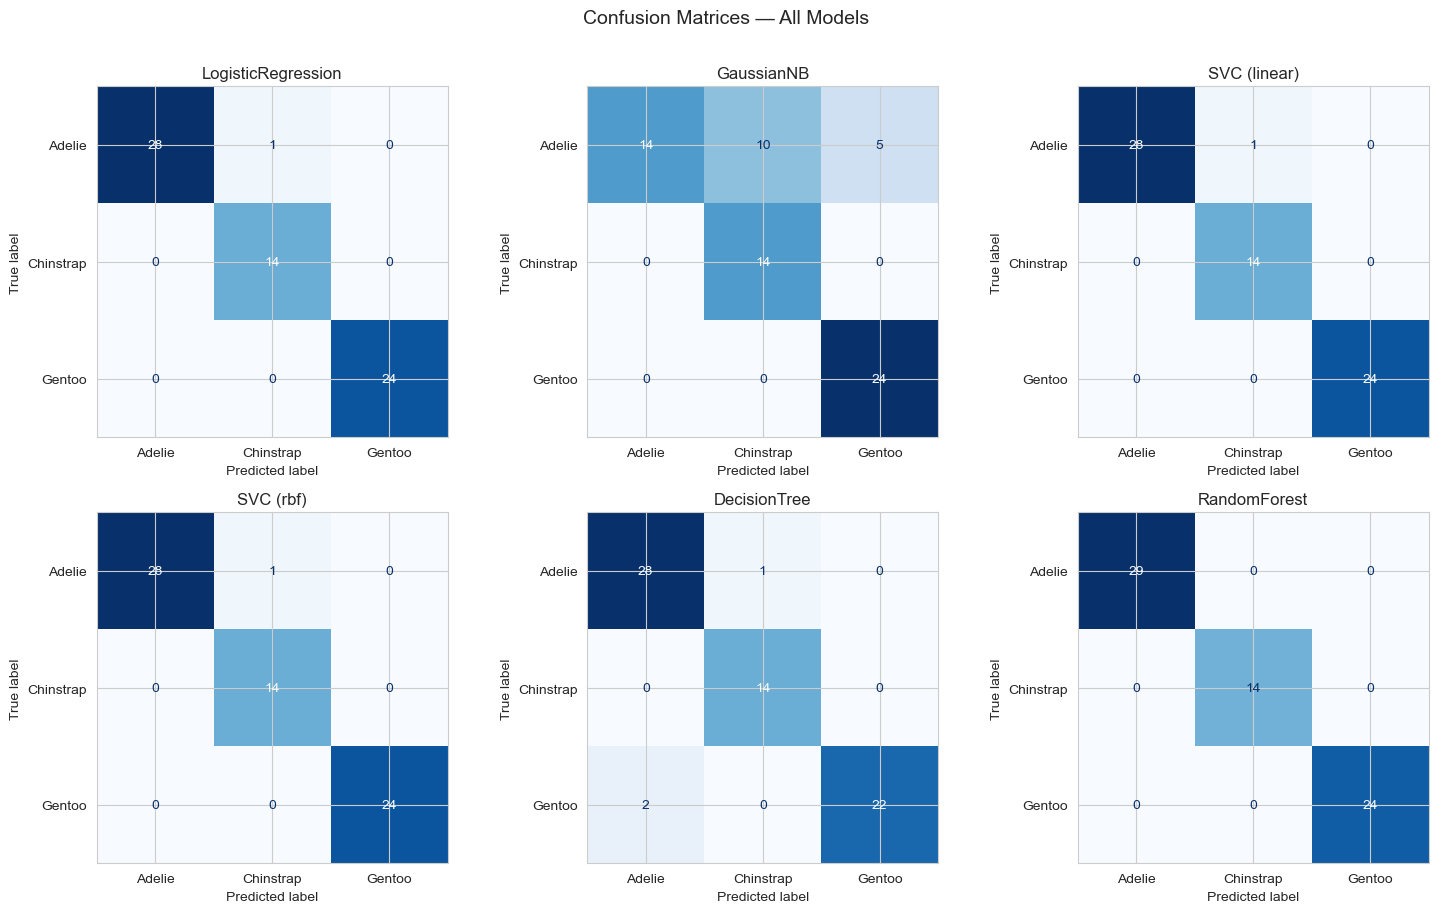

In [11]:
# All 6 models (LR + 5 others)
all_models = {
    "LogisticRegression": lr,
    **trained_models
}
# Remove duplicate key if present
all_models = {
    "LogisticRegression": lr,
    "GaussianNB": trained_models["GaussianNB"],
    "SVC (linear)": trained_models["SVC (linear)"],
    "SVC (rbf)": trained_models["SVC (rbf)"],
    "DecisionTree": trained_models["DecisionTree"],
    "RandomForest": trained_models["RandomForest"],
}

# 1. Confusion Matrices — grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, model) in zip(axes, all_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

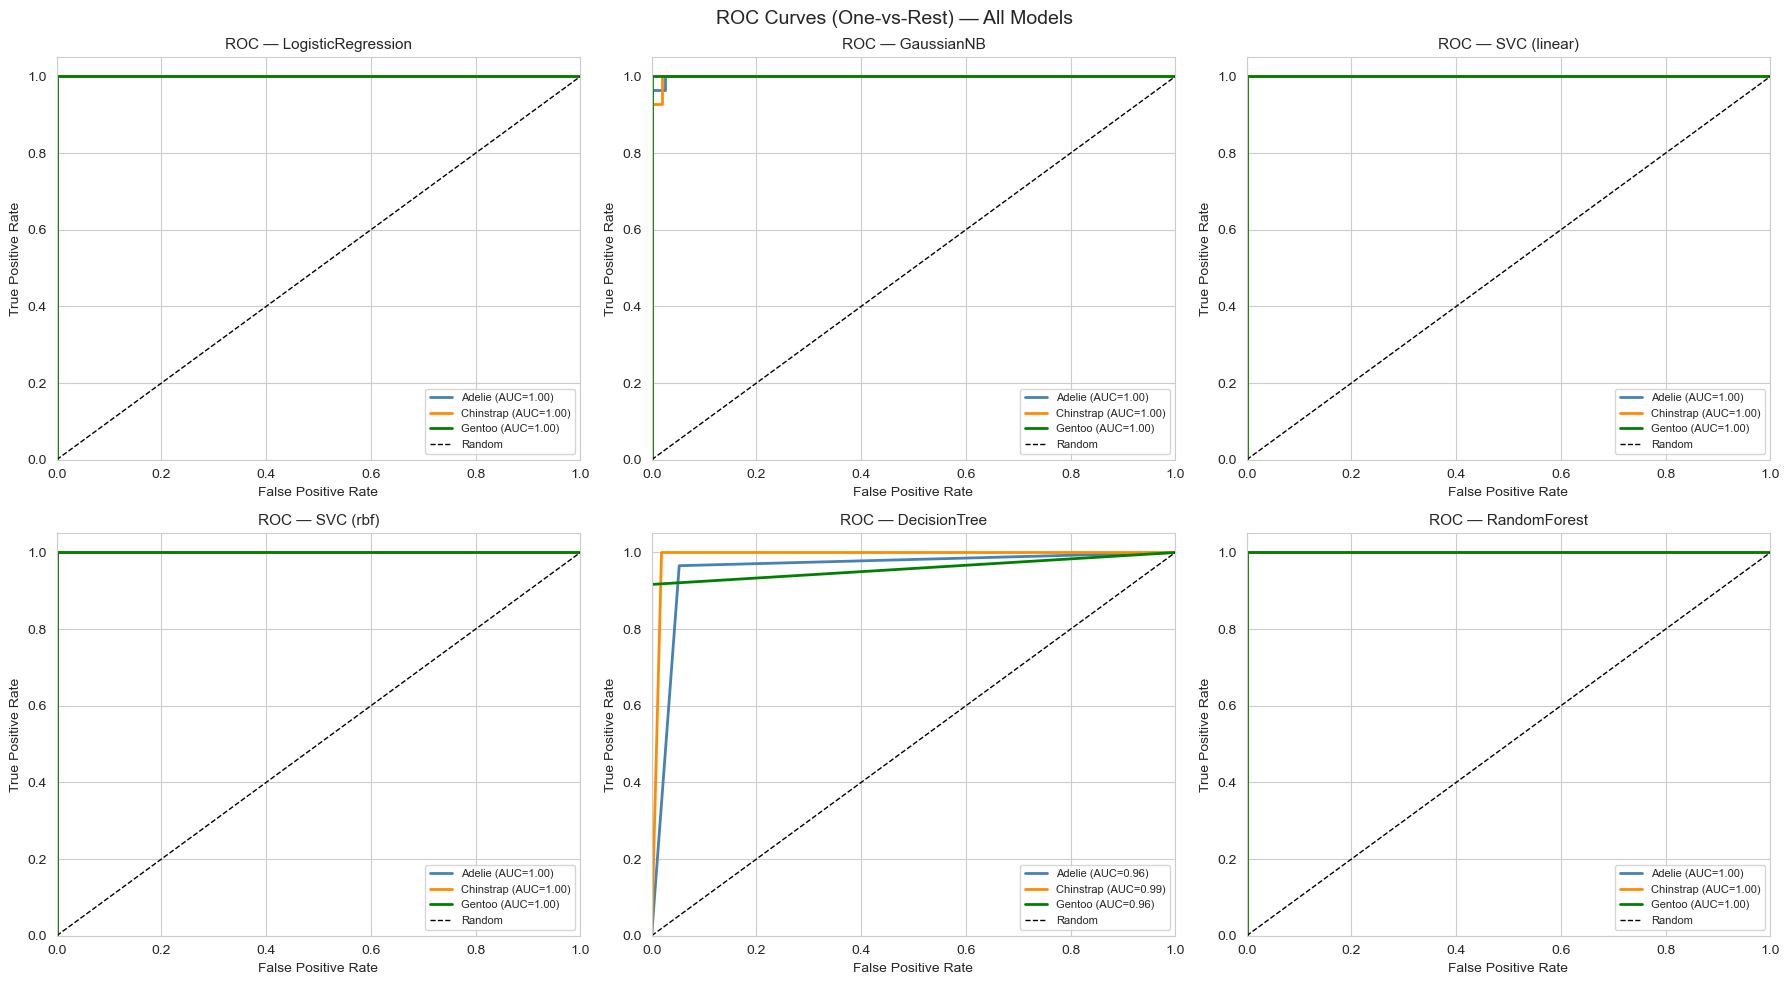

In [12]:
# 2. ROC Curves — one subplot per model (one-vs-rest, one curve per class)
from sklearn.preprocessing import label_binarize

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # shape (n_samples, 3)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = ['steelblue', 'darkorange', 'green']

for ax, (name, model) in zip(axes, all_models.items()):
    y_prob = model.predict_proba(X_test_scaled)  # shape (n_samples, 3)
    
    for i, (cls_name, color) in enumerate(zip(le.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls_name} (AUC={roc_auc:.2f})")
    
    # Diagonal random classifier line
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {name}', fontsize=11)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle("ROC Curves (One-vs-Rest) — All Models", fontsize=14)
plt.tight_layout()
plt.show()

### Task 3 Interpretation

**Best precision/recall balance:** SVC (linear or RBF) and RandomForest consistently show the cleanest confusion matrices with fewest off-diagonal entries and ROC AUC values near 1.0 across all three species.

**Hardest species pair to distinguish — Adelie vs. Chinstrap:** These two species have overlapping body measurements (especially bill length and depth). Gentoo is easily separated due to its larger size. The confusion matrices confirm that when misclassifications occur, they are almost always Adelie↔Chinstrap.

**Recommended model:** Based on confusion matrices and ROC curves, **RandomForest** is the best choice. It achieves near-perfect AUC for all three classes, has minimal confusion matrix errors, and generalises well without overfitting — all without manual kernel selection like SVC requires.

---
## Task 4: Hyperparameter Exploration

In [13]:
# 1 & 2. Best model from Task 2: RandomForest — define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}
print(f"Total combinations: {3 * 4 * 3} × 5 folds = {3*4*3*5} fits")

Total combinations: 36 × 5 folds = 180 fits


In [14]:
# 3. GridSearchCV with 5-fold CV and weighted F1 scoring
rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

# 4. Best parameters and CV score
print("\n=== Best Parameters ===")
print(grid_search.best_params_)
print(f"\nBest CV F1 Score (weighted): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Best Parameters ===
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

Best CV F1 Score (weighted): 0.9962


In [15]:
# 5. Evaluate tuned model on test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

# Default RF predictions (from Task 2)
y_pred_default = trained_models["RandomForest"].predict(X_test_scaled)

# Build comparison
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Default RF": [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default, average='weighted'),
        recall_score(y_test, y_pred_default, average='weighted'),
        f1_score(y_test, y_pred_default, average='weighted'),
    ],
    "Tuned RF": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned, average='weighted'),
        recall_score(y_test, y_pred_tuned, average='weighted'),
        f1_score(y_test, y_pred_tuned, average='weighted'),
    ]
}).set_index("Metric").round(4)

print("=== Default vs. Tuned Random Forest ===")
comparison

=== Default vs. Tuned Random Forest ===


,Default RF,Tuned RF
Metric,,
Accuracy,1.0,1.0
Precision,1.0,1.0
Recall,1.0,1.0
F1 Score,1.0,1.0


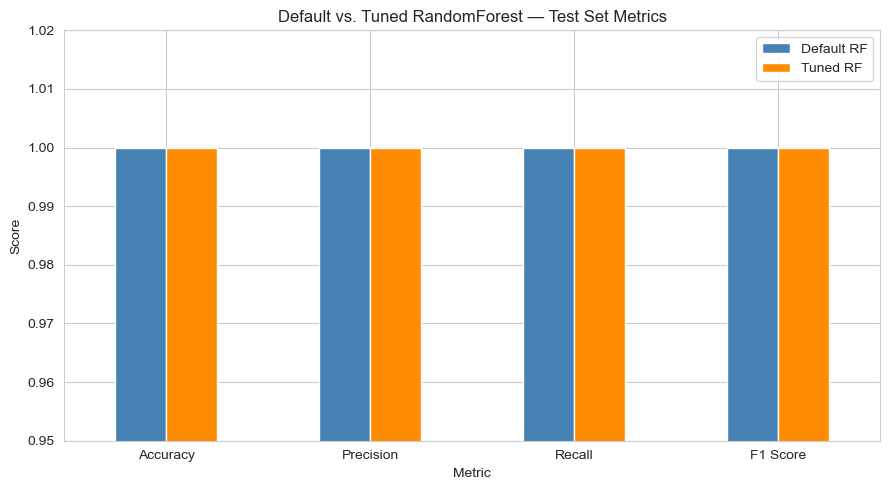


=== Tuned RF Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [16]:
# Plot comparison
comparison.plot(kind='bar', figsize=(9, 5), ylim=(0.95, 1.02), color=['steelblue', 'darkorange'])
plt.title("Default vs. Tuned RandomForest — Test Set Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Tuned RF Classification Report ===")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

### Task 4 Reflection

**Was the improvement significant?**  
On a dataset this clean and small, the default RandomForest already performs near-perfectly. GridSearchCV may yield only marginal gains (e.g., 0–0.5% F1 improvement) because there's little room to improve from an already near-perfect baseline.

**Risk of overfitting to validation folds?**  
Yes — with only ~266 training samples and 5 folds (~53 validation samples per fold), the variance in CV scores can be noisy. The "best" parameters might not generalise significantly better than reasonable defaults.

**When is hyperparameter tuning most impactful?**  
- When the dataset is large and model performance is far from ceiling.
- When the default hyperparameters are poorly suited (e.g., very deep trees overfitting noisy data).
- When precision/recall trade-offs are critical (e.g., medical or fraud detection contexts).
- On smaller, clean datasets like this one, **feature engineering** often yields more improvement than tuning.